###  Installation de l'environnement

In [12]:
%pip install -r ../../requirements.txt

ERROR: Could not open requirements file: [Errno 2] Aucun fichier ou dossier de ce nom: '../../requirements.txt'
Note: you may need to restart the kernel to use updated packages.


### Connexion à la DB DuckDB

In [13]:
import duckdb
import os
from pathlib import Path
from typing import List

import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


### Connexion à la DB / Import des Data


In [14]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

In [15]:
con.close()

In [4]:
df = con.execute("SELECT * FROM user_segments_kmeans").fetchdf()

In [5]:
# Feature engineering
df["is_active"] = (df["days_since_last_event"] < 30).astype(int)

In [6]:
# Séparation features / cibles
X = df.drop(columns=["segment", "user_id", "last_event_time"])
y = df["segment"]

In [7]:
X

,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,conversion_rate,purchase_ratio,days_since_last_event,category_embedding,is_active
0,83,77.0,0.0,101660.951220,0.00,0.000000,0.000000,0.000000,37,"[0.35857014219189, 0.2146849604615403, 0.66510...",0
1,167,140.0,7.0,76679.114458,3763.02,537.574286,0.050000,0.047619,32,"[0.541805149360225, 0.29873900777542917, 0.609...",0
2,166,153.0,5.0,36154.878788,925.98,185.196000,0.032680,0.031646,96,"[0.677823864283297, -0.19088278029106448, -0.0...",0
3,59,51.0,1.0,117231.810345,282.86,282.860000,0.019608,0.019231,59,"[0.36524954182900954, 0.4529579710213816, -0.1...",0
4,103,93.0,1.0,54209.186275,493.96,493.960000,0.010753,0.010638,84,"[0.23150635567652902, 0.24461066076096485, 0.4...",0
...,...,...,...,...,...,...,...,...,...,...,...
4900,27,25.0,2.0,76675.807692,131.79,65.895000,0.080000,0.074074,159,"[0.223866140498235, 0.23939956580190141, -0.01...",0
4901,18,18.0,0.0,144.705882,0.00,0.000000,0.000000,0.000000,84,"[0.8899611793437568, -0.35902182733139465, -0....",0
4902,11,11.0,0.0,217659.300000,0.00,0.000000,0.000000,0.000000,149,"[0.3904866375637094, 0.6501394777730585, -0.58...",0
4903,16,16.0,0.0,533915.133333,0.00,0.000000,0.000000,0.000000,41,"[0.8902528008836732, -0.4115924806048521, -0.0...",0


In [8]:
X.drop(columns=["category_embedding"], inplace=True)

In [9]:
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

Meilleurs hyperparamètres trouvés :
{'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Score moyen : 0.8634073183413493
Rapport de classification :
              precision    recall  f1-score   support

           0       0.78      0.77      0.78       283
           1       0.85      0.87      0.86       345
           2       0.97      0.97      0.97        67
           3       0.95      0.93      0.94       235
           4       1.00      1.00      1.00         1
           5       0.94      0.94      0.94        50

    accuracy                           0.87       981
   macro avg       0.92      0.91      0.91       981
weighted avg       0.87      0.87      0.87       981



<Figure size 600x500 with 0 Axes>

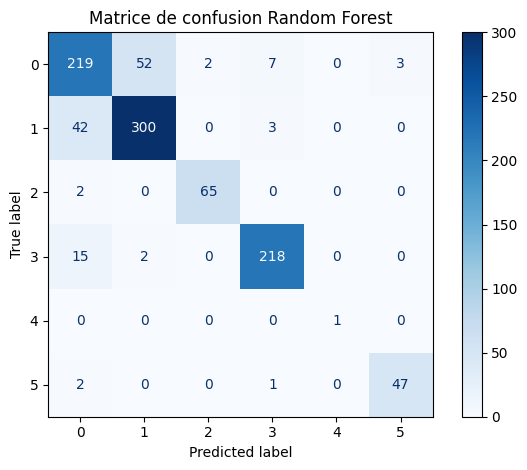

In [11]:


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=42))
])

# Paramètres à tester
param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [10, 20, 30],
    "clf__min_samples_split": [2, 5],
    "clf__max_features": ['sqrt', 'log2']
}

# Cross-validation stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch avec cross-validation
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

# Résultats
print("Meilleurs hyperparamètres trouvés :")
print(grid.best_params_)

print("Score moyen :", grid.best_score_)

# Prédictions finales (pour reporting)
y_pred = grid.predict(X_test)

# Rapport de classification
print("Rapport de classification :")
print(classification_report(y_test, y_pred))
# Matrice de confusion
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=grid.classes_, cmap="Blues")
plt.title("Matrice de confusion Random Forest")
plt.tight_layout()
plt.show()

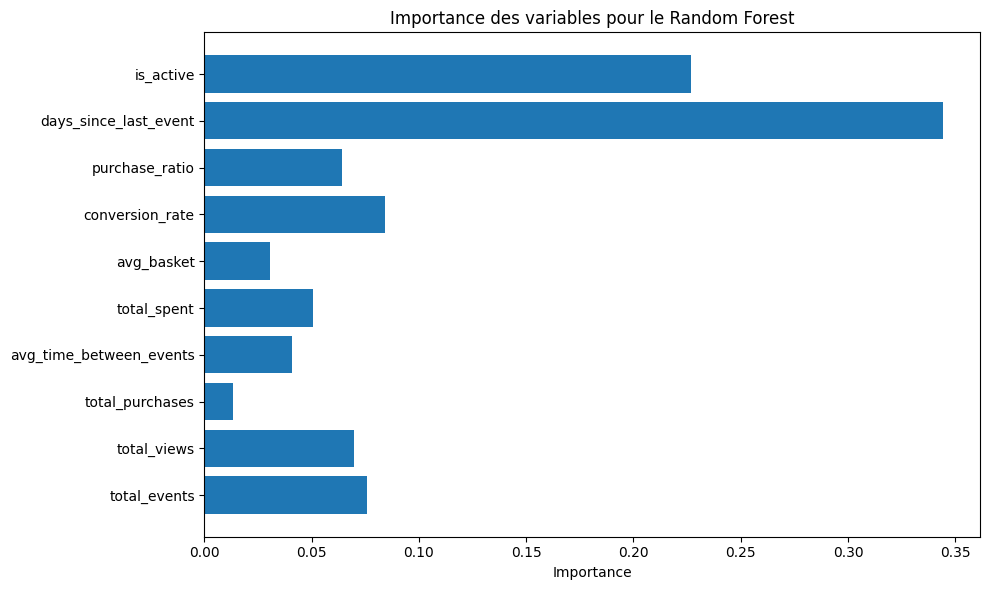

In [ ]:
best_rf = grid.best_estimator_.named_steps["clf"]

# Affiche l'importance des features
importances = best_rf.feature_importances_
features = X.columns

# Affichage en barres
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Importance des variables pour le Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
# Fermeture de la connexion DuckDB
con.close()